In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
orders = pd.read_csv('/content/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/olist_order_items_dataset.csv')
products = pd.read_csv('/content/olist_products_dataset.csv')
customers = pd.read_csv('/content/olist_customers_dataset.csv')
reviews = pd.read_csv('/content/olist_order_reviews_dataset.csv')

print("Files loaded successfully!")

Files loaded successfully!


In [3]:
print("Orders Shape:", orders.shape)
print("Order Items Shape:", order_items.shape)
print("Products Shape:", products.shape)
print("Customers Shape:", customers.shape)
print("Reviews Shape:", reviews.shape)

Orders Shape: (99441, 8)
Order Items Shape: (112650, 7)
Products Shape: (32951, 9)
Customers Shape: (99441, 5)
Reviews Shape: (99224, 7)


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
print("Orders Missing Values:")
print(orders.isnull().sum())

print("\nOrder Items Missing Values:")
print(order_items.isnull().sum())

print("\nProducts Missing Values:")
print(products.isnull().sum())

print("\nCustomers Missing Values:")
print(customers.isnull().sum())

print("\nReviews Missing Values:")
print(reviews.isnull().sum())

Orders Missing Values:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

Order Items Missing Values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

Products Missing Values:
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Customers Missing Values:
customer_id                 0
customer_unique_id          0
customer_zi

In [6]:
print("Orders Duplicates:", orders.duplicated().sum())
print("Order Items Duplicates:", order_items.duplicated().sum())
print("Products Duplicates:", products.duplicated().sum())
print("Customers Duplicates:", customers.duplicated().sum())
print("Reviews Duplicates:", reviews.duplicated().sum())

Orders Duplicates: 0
Order Items Duplicates: 0
Products Duplicates: 0
Customers Duplicates: 0
Reviews Duplicates: 0


In [7]:
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()
products = products.drop_duplicates()
customers = customers.drop_duplicates()
reviews = reviews.drop_duplicates()

print("Duplicates removed!")

Duplicates removed!


In [8]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

print("Date column converted successfully!")

Date column converted successfully!


In [9]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  object        
 5   order_delivered_carrier_date   97658 non-null  object        
 6   order_delivered_customer_date  96476 non-null  object        
 7   order_estimated_delivery_date  99441 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 6.1+ MB


In [10]:
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

print("All date columns converted successfully!")

All date columns converted successfully!


In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [12]:
sales_data = orders.merge(order_items, on='order_id', how='inner')
sales_data = sales_data.merge(products, on='product_id', how='left')
sales_data = sales_data.merge(customers, on='customer_id', how='left')
sales_data = sales_data.merge(reviews, on='order_id', how='left')

print("Merged Dataset Shape:", sales_data.shape)
sales_data.head()

Merged Dataset Shape: (113314, 32)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51


In [13]:
print(sales_data.columns.tolist())

['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']


In [14]:
category_revenue = sales_data.groupby('product_category_name')['price'].sum().sort_values(ascending=False)

print(category_revenue.head(10))

product_category_name
beleza_saude              1263138.54
relogios_presentes        1206075.33
cama_mesa_banho           1050936.61
esporte_lazer              993656.51
informatica_acessorios     919640.54
moveis_decoracao           736282.47
cool_stuff                 637258.51
utilidades_domesticas      634542.60
automotivo                 594363.10
ferramentas_jardim         486432.45
Name: price, dtype: float64


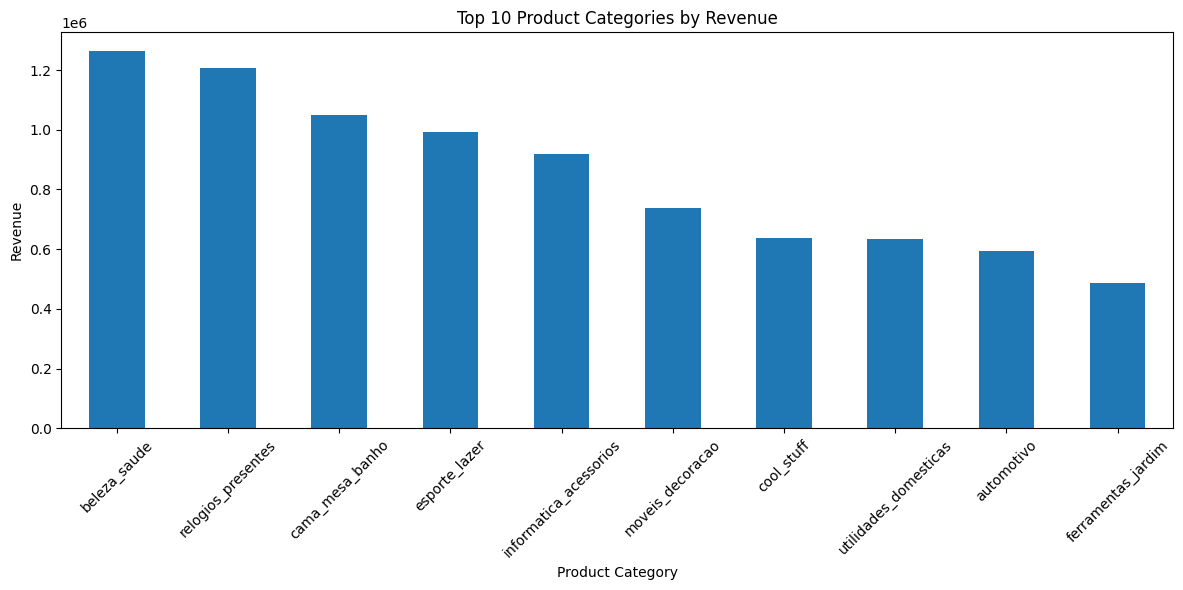

In [15]:
plt.figure(figsize=(12,6))
category_revenue.head(10).plot(kind='bar')
plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
sales_data['month'] = sales_data['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = sales_data.groupby('month')['price'].sum()

print(monthly_sales.sort_values(ascending=False).head())

month
2017-11    1017758.83
2018-04     998893.07
2018-05     997066.66
2018-03     986867.05
2018-01     955658.74
Freq: M, Name: price, dtype: float64


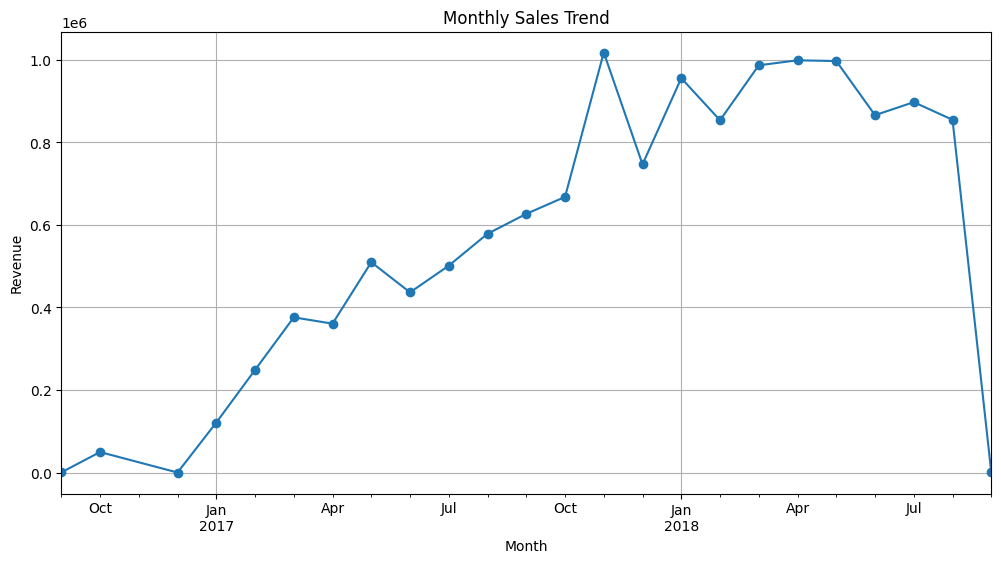

In [17]:
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.show()

In [18]:
print(monthly_sales.sort_values(ascending=False).head(10))

month
2017-11    1017758.83
2018-04     998893.07
2018-05     997066.66
2018-03     986867.05
2018-01     955658.74
2018-07     897496.14
2018-06     865956.24
2018-08     854760.45
2018-02     853591.21
2017-12     746717.15
Freq: M, Name: price, dtype: float64


In [19]:
region_sales = sales_data.groupby('customer_state')['price'].sum().sort_values(ascending=False)

print(region_sales.head(10))

customer_state
SP    5228869.17
RJ    1831678.85
MG    1591518.47
RS     754250.33
PR     685911.51
SC     522120.11
BA     513182.78
DF     304658.17
GO     297535.49
ES     275910.68
Name: price, dtype: float64


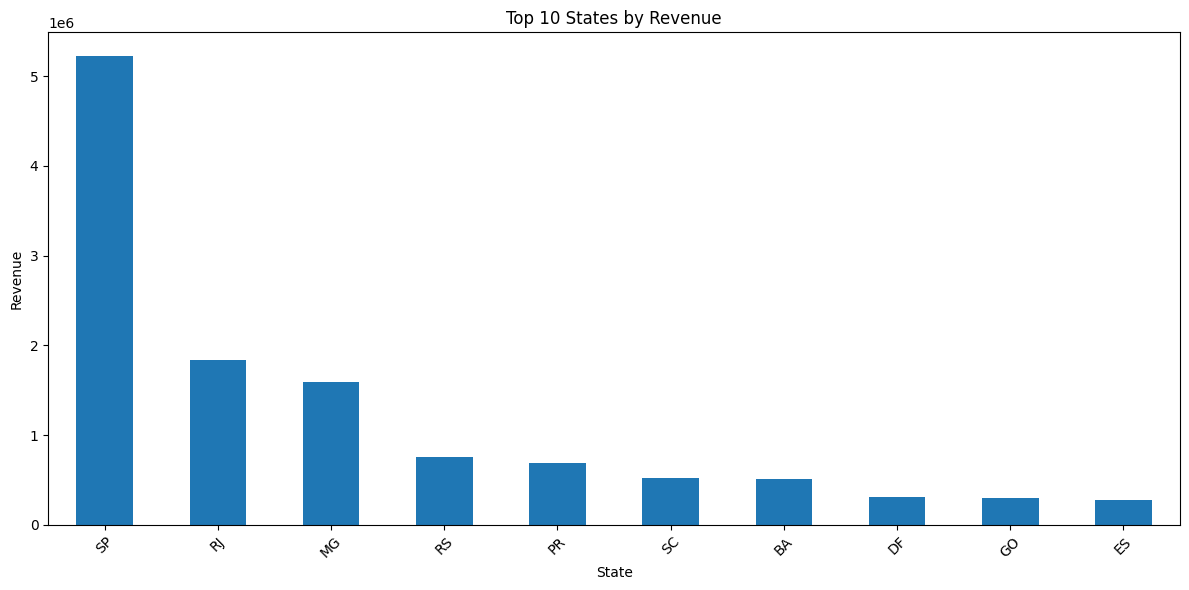

In [20]:
plt.figure(figsize=(12,6))
region_sales.head(10).plot(kind='bar')
plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
print(region_sales.head(10))

customer_state
SP    5228869.17
RJ    1831678.85
MG    1591518.47
RS     754250.33
PR     685911.51
SC     522120.11
BA     513182.78
DF     304658.17
GO     297535.49
ES     275910.68
Name: price, dtype: float64


In [22]:
order_value = sales_data.groupby('order_id')['price'].sum().reset_index()

order_month = sales_data[['order_id', 'order_purchase_timestamp']].drop_duplicates()

aov_data = order_value.merge(order_month, on='order_id')

aov_data['month'] = aov_data['order_purchase_timestamp'].dt.to_period('M')

monthly_aov = aov_data.groupby('month')['price'].mean()

print(monthly_aov.head())

month
2016-09     89.120000
2016-10    161.150487
2016-12     10.900000
2017-01    153.470089
2017-02    143.429325
Freq: M, Name: price, dtype: float64


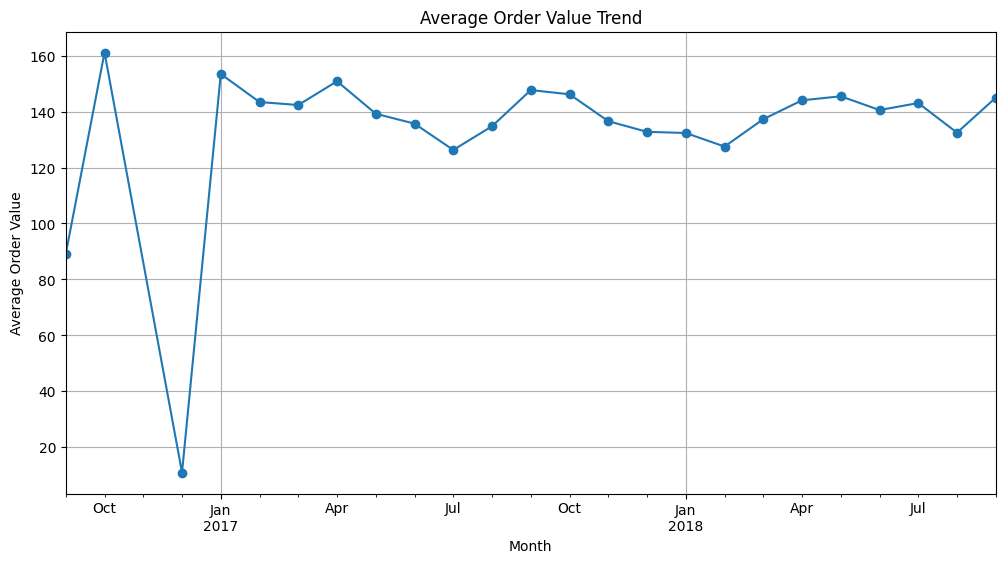

In [23]:
plt.figure(figsize=(12,6))
monthly_aov.plot(kind='line', marker='o')
plt.title('Average Order Value Trend')
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.grid(True)
plt.show()

In [24]:
print(monthly_aov.sort_values(ascending=False).head(10))

month
2016-10    161.150487
2017-01    153.470089
2017-04    150.873346
2017-09    147.714393
2017-10    146.206031
2018-05    145.493457
2018-09    145.000000
2018-04    144.057264
2017-02    143.429325
2018-07    143.072874
Freq: M, Name: price, dtype: float64


In [25]:
print(sales_data['review_score'].value_counts().sort_index())

review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64


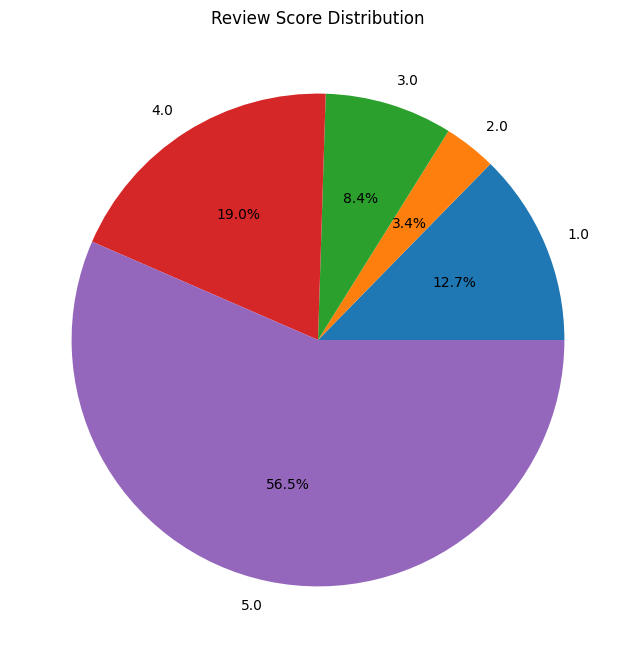

In [26]:
review_counts = sales_data['review_score'].value_counts().sort_index()

plt.figure(figsize=(8,8))
plt.pie(review_counts,
        labels=review_counts.index,
        autopct='%1.1f%%')

plt.title('Review Score Distribution')
plt.show()

In [27]:
print(sales_data['review_score'].value_counts().sort_index())

review_score
1.0    14235
2.0     3874
3.0     9423
4.0    21315
5.0    63525
Name: count, dtype: int64


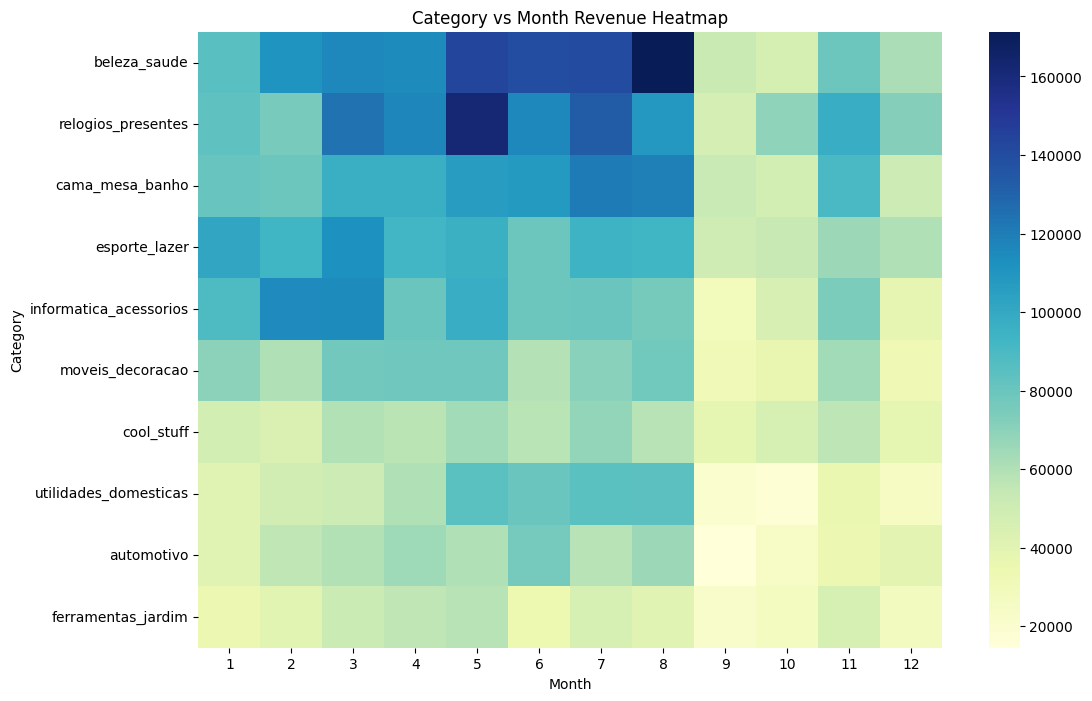

In [28]:
sales_data['month_num'] = sales_data['order_purchase_timestamp'].dt.month

heatmap_data = pd.pivot_table(
    sales_data,
    values='price',
    index='product_category_name',
    columns='month_num',
    aggfunc='sum',
    fill_value=0
)

top_categories = sales_data.groupby('product_category_name')['price'].sum() \
                           .sort_values(ascending=False) \
                           .head(10).index

heatmap_top = heatmap_data.loc[top_categories]

plt.figure(figsize=(12,8))
sns.heatmap(heatmap_top, cmap='YlGnBu')
plt.title('Category vs Month Revenue Heatmap')
plt.xlabel('Month')
plt.ylabel('Category')
plt.show()

In [29]:
total_revenue = sales_data['price'].sum()

total_orders = sales_data['order_id'].nunique()

top_category = sales_data.groupby('product_category_name')['price'].sum().idxmax()

best_month = monthly_sales.idxmax()

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Top Category:", top_category)
print("Best Month:", best_month)

Total Revenue: 13651923.469999999
Total Orders: 98666
Top Category: beleza_saude
Best Month: 2017-11


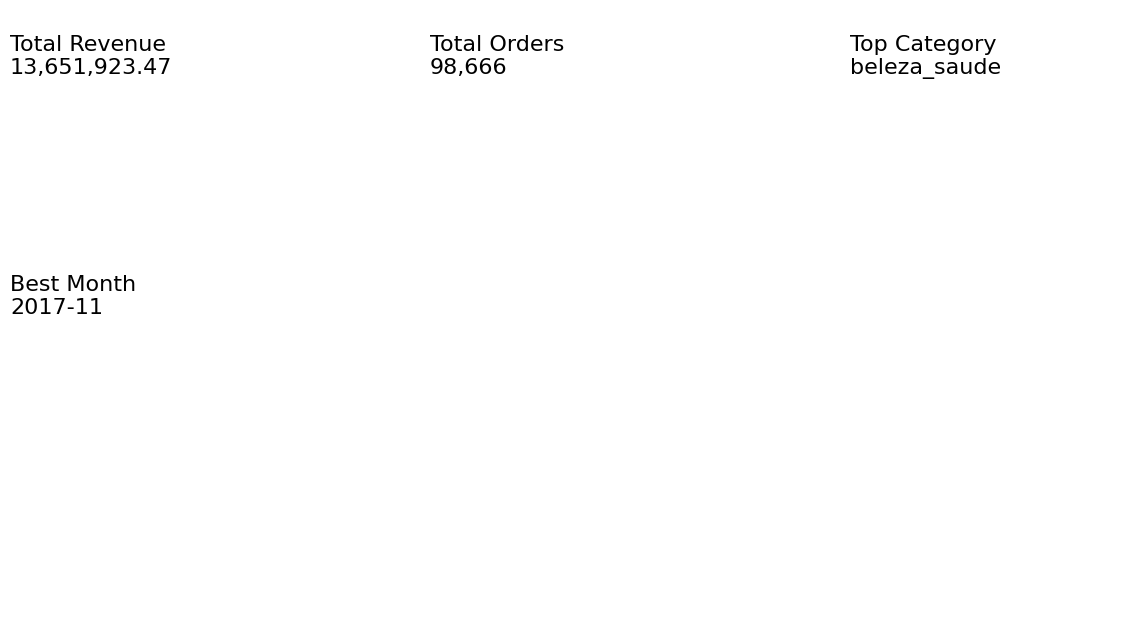

In [30]:
fig = plt.figure(figsize=(14,8))

fig.text(0.1, 0.8, f'Total Revenue\n{total_revenue:,.2f}', fontsize=16)
fig.text(0.4, 0.8, f'Total Orders\n{total_orders:,}', fontsize=16)
fig.text(0.7, 0.8, f'Top Category\n{top_category}', fontsize=16)
fig.text(0.1, 0.5, f'Best Month\n{best_month}', fontsize=16)

plt.axis('off')
plt.show()

# Business Insights Report

## Insight 1
The Beauty & Health (beleza_saude) category generated the highest revenue among all categories.
Recommendation: Increase marketing campaigns and inventory for this category to maximize revenue growth.

## Insight 2
November 2017 recorded the highest sales revenue (1,017,758.83), indicating strong seasonal demand.
Recommendation: Launch promotional campaigns before November to capitalize on peak customer activity.

## Insight 3
The state of SP contributed the highest revenue (5,228,869.17), significantly outperforming other regions.
Recommendation: Focus regional marketing efforts and customer retention programs in SP.

## Insight 4
Average Order Value peaked at 161.15 in October 2016, showing customers were spending more per order during that period.
Recommendation: Encourage larger purchases through bundles, discounts, and cross-selling strategies.

## Insight 5
Most customers gave 5-star reviews, indicating high customer satisfaction.
Recommendation: Maintain product quality and customer service standards while investigating low-rated reviews for improvement opportunities.

# Most Surprising Finding

The most surprising finding was the dominance of the Beauty & Health category in overall revenue generation. Despite having many product categories available, this category significantly outperformed others. Another interesting observation was that a single state (SP) contributed a very large share of total sales. Additionally, customer satisfaction was exceptionally high, with most reviews receiving 5-star ratings. These findings highlight strong opportunities for targeted marketing and regional business expansion.